<img src = "https://drive.google.com/uc?export=view&id=1kl2OFnF2FADAAKjgZUFPo8dsBQUSIJM7" alt = "Encabezado MLDS" width = "100%">  </img>

# **Entendimiento y Preparación de los Datos**
---

Este notebook es una plantilla que le puede servir como guía para el segundo entregable del proyecto aplicado.

## Grupo No. 2
---
- Santiago Ruiz Rozo <<sruiz899@gmail.com>>
- Pablo Alejandro Reyes Granados <<alejogranados229@gmail.com>>
- Kevin Andrés Martínez Martínez <<kevinmartinez.ingbiom@gmail.com>>

## Cargar Datos

In [1]:
import tarfile
import nibabel as nib
import matplotlib.pyplot as plt
import cv2
import os

!curl -L "https://drive.google.com/uc?export=download&id=1RzPB1_bqzQhlWvU-YGvZzhx2omcDh38C" -o "Task04_Hippocampus.tar"
!tar -xf Task04_Hippocampus.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 27.1M  100 27.1M    0     0  3274k      0  0:00:08  0:00:08 --:--:-- 6918k


## Inspeccion Inicial de Shapes

In [10]:
import os, re, nibabel as nib
import numpy as np
from collections import defaultdict

ROOT = "/content/Task04_Hippocampus"
IMG_DIR = os.path.join(ROOT, "imagesTr")
LBL_DIR = os.path.join(ROOT, "labelsTr")

def _valid_nii_list(path):
    files = [
        f for f in os.listdir(path)
        if (f.endswith((".nii", ".nii.gz")) and not f.startswith("._"))]
    def key_fn(fn):
        m = re.search(r'(\d+)', fn)
        return int(m.group(1)) if m else fn
    return sorted(files, key=key_fn)

img_files = _valid_nii_list(IMG_DIR)
lbl_files = _valid_nii_list(LBL_DIR)

print(f"# imgs: {len(img_files)} | # labels: {len(lbl_files)}")
print("Ejemplos IMG:", img_files[:5])
print("Ejemplos LBL:", lbl_files[:5])

def basename_noext(fn):
    return re.sub(r'\.nii(\.gz)?$', '', fn)

imgs_map = {basename_noext(f): f for f in img_files}
lbls_map = {basename_noext(f): f for f in lbl_files}
common = sorted(set(imgs_map.keys()) & set(lbls_map.keys()))

if not common:
    raise RuntimeError("No hay pares imagen–máscara con el mismo nombre base.")

print(f"Pares imagen–máscara encontrados: {len(common)} (de {len(img_files)} imgs y {len(lbl_files)} labels)")

def quick_meta(nifti_path):
    img = nib.load(nifti_path)
    shape = img.shape
    zooms = img.header.get_zooms()
    dtype = img.get_data_dtype()
    return shape, zooms, dtype

mismatch = []
shapes_count = defaultdict(int)
voxel_sizes = defaultdict(int)
c=0

print()
for k in common:
    ip = os.path.join(IMG_DIR, imgs_map[k])
    lp = os.path.join(LBL_DIR, lbls_map[k])

    ishape, izooms, idt = quick_meta(ip)
    lshape, lzooms, ldt = quick_meta(lp)

    shapes_count[ishape] += 1
    voxel_sizes[tuple(round(z, 3) for z in izooms[:3])] += 1

    if ishape != lshape:
        mismatch.append((k, ishape, lshape))

    if c == 19:
      print(f'Se presentan los Shapes de las Primeras {c+1} imaganes:')
      break
    else:
      c = c +1

print("\n=== Resumen Shapes (imágenes) ===")
for shp, cnt in sorted(shapes_count.items(), key=lambda x: (-x[1], x[0])):
    print(f"  {shp}: {cnt} volúmenes")

print("\n=== Resumen Voxel sizes (mm, imágenes) ===")
for vz, cnt in sorted(voxel_sizes.items(), key=lambda x: (-x[1], x[0])):
    print(f"  {vz}: {cnt} volúmenes")

if mismatch:
    print("MISMATCH imagen–label (shapes distintos):")
    for k, si, sl in mismatch[:10]:
        print(f"  {k}: img {si} vs lbl {sl}")
    print(f"Total mismatches: {len(mismatch)}")
else:
    print("Todos los pares img–label tienen el MISMO shape.")

N_CHECK = 5
print(f"\nChequeo rápido de valores únicos en {N_CHECK} máscaras:")
for k in common[:N_CHECK]:
    lp = os.path.join(LBL_DIR, lbls_map[k])
    arr = np.asanyarray(nib.load(lp).dataobj)
    uniq = np.unique(arr)
    print(f"  {k}: únicos={uniq[:10]}{'...' if uniq.size>10 else ''} dtype={arr.dtype}")

# imgs: 260 | # labels: 260
Ejemplos IMG: ['hippocampus_001.nii.gz', 'hippocampus_003.nii.gz', 'hippocampus_004.nii.gz', 'hippocampus_006.nii.gz', 'hippocampus_007.nii.gz']
Ejemplos LBL: ['hippocampus_001.nii.gz', 'hippocampus_003.nii.gz', 'hippocampus_004.nii.gz', 'hippocampus_006.nii.gz', 'hippocampus_007.nii.gz']
Pares imagen–máscara encontrados: 260 (de 260 imgs y 260 labels)

Se presentan los Shapes de las Primeras 20 imaganes:

=== Resumen Shapes (imágenes) ===
  (35, 51, 35): 2 volúmenes
  (33, 48, 38): 1 volúmenes
  (34, 47, 40): 1 volúmenes
  (34, 52, 35): 1 volúmenes
  (35, 47, 37): 1 volúmenes
  (35, 48, 32): 1 volúmenes
  (35, 48, 35): 1 volúmenes
  (35, 52, 34): 1 volúmenes
  (36, 46, 43): 1 volúmenes
  (36, 47, 39): 1 volúmenes
  (36, 47, 41): 1 volúmenes
  (36, 48, 40): 1 volúmenes
  (36, 49, 40): 1 volúmenes
  (36, 50, 31): 1 volúmenes
  (36, 50, 36): 1 volúmenes
  (36, 52, 38): 1 volúmenes
  (38, 52, 33): 1 volúmenes
  (39, 50, 40): 1 volúmenes
  (42, 51, 28): 1 volúme

## **0. Entendiendo la Composicion de los Datos**

En el contexto de segmentación médica, cada **imagen** corresponde a un **volumen tridimensional** obtenido a partir de técnicas como MRI o CT.  
A diferencia de una imagen convencional 2D, un volumen 3D se compone de una pila de cortes bidimensionales (slices), los cuales juntos forman una representación completa del órgano o región anatómica de interés.

### 1. Estructura general del tensor

Cada volumen se representa como un **tensor tridimensional** con forma:

$$
(X, Y, Z)
$$

donde:
- **X** → número de voxeles a lo largo del eje izquierda–derecha,  
- **Y** → número de voxeles a lo largo del eje anterior–posterior (frente–espalda),  
- **Z** → número de cortes o “slices” en el eje superior–inferior (de la cabeza a los pies).

Por ejemplo, una imagen con shape `(35, 51, 35)` contiene:

$$
35 \times 51 \times 35 = 62{,}475 \text{ voxeles}
$$

Cada **voxel (volume element)** es el equivalente tridimensional de un píxel y almacena la **intensidad del MRI** en esa posición espacial.



### **Volúmenes y máscaras**

Para tareas de **segmentación**, cada volumen $ I $ tiene asociada una **máscara** $ M $ del mismo tamaño, donde cada voxel del tensor $ M_{x,y,z} $ indica la clase o región anatómica a la que pertenece el voxel correspondiente en $ I_{x,y,z} $.

Por ejemplo:
- `0` → fondo,  
- `1` → hipocampo izquierdo,  
- `2` → hipocampo derecho.

Ambos tensores —imagen y máscara— tienen dimensiones idénticas $(X, Y, Z)$, permitiendo compararlos voxel a voxel durante el entrenamiento de una red neuronal.



### **Voxel size y resolución espacial**

Además del shape, cada volumen contiene información sobre el **tamaño físico del voxel** en milímetros, almacenada en los *metadata* del archivo NIfTI (campo `zooms`).  
Por ejemplo:

$$
\text{zooms} = (1.0, 1.0, 1.0)
$$

indica que cada voxel representa un cubo de $1\,\text{mm}^3$.  
Si los valores son diferentes (p. ej. `(0.8, 0.8, 1.2)`), el volumen es **anisotrópico**, es decir, los voxeles no tienen la misma escala en todos los ejes.


### **Interpretación geométrica**

Visualmente, un tensor 3D puede entenderse como una pila de imágenes 2D:

```bash
MRI volumen (3D)
↑ eje Z (slices)
│
├── slice_00 → imagen 2D (X × Y)
├── slice_01 → imagen 2D (X × Y)
├── slice_02 → imagen 2D (X × Y)
...
└── slice_Z-1
```

Cada **slice** es una proyección plana del volumen y puede visualizarse individualmente, pero el conjunto completo de cortes constituye la verdadera información tridimensional utilizada en modelos 3D como **UNet3D**, **VNet** o **nnU-Net**.

### **Tensor final en frameworks de deep learning**

Al trabajar con PyTorch o MONAI, es común añadir un canal explícito al volumen, de modo que cada muestra tenga la forma:

$$
(1, X, Y, Z)
$$

donde el primer eje (`1`) representa el canal de intensidad (similar a “escala de grises”).  
Si se usan varios canales (p. ej. distintas modalidades de MRI), el tensor podría tener forma `(C, X, Y, Z)` con \(C>1\).


## **1. Análisis Exploratorio de los Datos**
---

Normalmente en el análisis exploratorio, se trata de dar respuesta a los siguientes elementos:

### **1.1. Resumen General**
---

- **¿Cuántos documentos tiene el dataset?**
    
    Se recuperan 260 imagenes 3D para el entrenamiento con su etiqueta (mascara de segmentación) y 130 imagenes 3D para pruebas. Eso quiere decir que la partición del dataset en muestra de entrenamiento es del 66.66% y prueba es del 33.33%.

- **¿En qué formato están guartdados los datos?**

    La extensiónd de las imagenes es de tipo .nii, creado por Neuroimaging Informatics Technology Initiative. Este tipo de datos es comunmente usado para almacenar imagenes de resonancia magnetic (MRI). Es este caso, son imagenes del cerebro.

- **¿Qué tamaño en MB tiene el conjunto?**

    El archivo comprimido tiene un tamaño de 28 MB. Este valor se compone de 18.1 MB en imagenes para entrenamiento, 8.8 MB en imagenes para pruebas y 1.1 MB en las etiquetas (al ser un problema de segmentación, las etiquetas también son un tensor con las mismas dimensiones de las imagenes de entrada).

### **1.2. Resumen de la Calidad de los datos**
---


- ¿Hay datos faltantes, documentos vacíos o de mala calidad?

In [17]:
ROOT = "/content/Task04_Hippocampus"
DIRS = {"imagesTr":"imagesTr", "labelsTr":"labelsTr", "imagesTs":"imagesTs"}
JSON_PATH = os.path.join(ROOT, "dataset.json")

def list_valid(path):
    return sorted([f for f in os.listdir(path)
                   if (f.endswith((".nii",".nii.gz")) and not f.startswith("._"))])

def bname(fn):
    return re.sub(r'\.nii(\.gz)?$', '', fn)

def quick_subsample_stats(nifti_path, step=4):
    """Carga 'económico': submuestrea cada 'step' voxeles para chequear NaN/Inf/var."""
    img = nib.load(nifti_path)
    arr = np.asanyarray(img.dataobj)[::step, ::step, ::step]
    if arr.size == 0:
        return {"empty": True, "finite_ok": False, "var": 0.0}
    finite = np.isfinite(arr)
    var = float(arr.var()) if finite.any() else 0.0
    return {"empty": False, "finite_ok": finite.all(), "var": var}

issues = []
for k,d in DIRS.items():
    p = os.path.join(ROOT,d)
    if not os.path.isdir(p):
        issues.append(f"FALTA directorio: {d}")

if not os.path.isfile(JSON_PATH):
    issues.append("FALTA dataset.json")

imgs = list_valid(os.path.join(ROOT,"imagesTr")) if os.path.isdir(os.path.join(ROOT,"imagesTr")) else []
lbls = list_valid(os.path.join(ROOT,"labelsTr")) if os.path.isdir(os.path.join(ROOT,"labelsTr")) else []
tsts = list_valid(os.path.join(ROOT,"imagesTs")) if os.path.isdir(os.path.join(ROOT,"imagesTs")) else []

imgs_map = {bname(f): f for f in imgs}
lbls_map = {bname(f): f for f in lbls}

only_img = sorted(set(imgs_map) - set(lbls_map))
only_lbl = sorted(set(lbls_map) - set(imgs_map))
common  = sorted(set(imgs_map) & set(lbls_map))

if only_img: issues.append(f"{len(only_img)} imágenes sin label (p.ej. {only_img[:3]})")
if only_lbl: issues.append(f"{len(only_lbl)} labels sin imagen (p.ej. {only_lbl[:3]})")
if not common and imgs and lbls:
    issues.append("No hay nombres base comunes entre imagesTr y labelsTr.")

def check_files(dir_path, files, label_mode=False, max_list=5):
    bad = {"size0":[], "corrupt":[], "naninf":[], "zerovar":[], "emptyslice":[]}
    for f in files:
        fp = os.path.join(dir_path, f)

        if os.path.getsize(fp) == 0:
            bad["size0"].append(f);continue

        try:
            img = nib.load(fp)
            shp = img.shape
            if any(s == 0 for s in shp):
                bad["emptyslice"].append((f, shp))

            st = quick_subsample_stats(fp, step=4)
            if st["empty"]:
                bad["emptyslice"].append((f, shp))

            if not st["finite_ok"]:
                bad["naninf"].append(f)

            if not label_mode and st["var"] < 1e-8:
                bad["zerovar"].append(f)
        except Exception as e:
            bad["corrupt"].append(f)
    def show(tag):
        arr = bad[tag]
        return f"{tag}: {len(arr)}" + (f" (ej: {arr[:max_list]})" if arr else "")
    return bad, " | ".join([show(k) for k in ["size0","corrupt","naninf","zerovar","emptyslice"]])

bad_img, sum_img = check_files(os.path.join(ROOT,"imagesTr"), imgs, label_mode=False)
bad_lbl, sum_lbl = check_files(os.path.join(ROOT,"labelsTr"), lbls, label_mode=True)
bad_tst, sum_tst = check_files(os.path.join(ROOT,"imagesTs"), tsts, label_mode=False) if tsts else ({}, "sin test o no verificado")

mismatch = []
for k in common[:]:
    ip = os.path.join(ROOT,"imagesTr", imgs_map[k])
    lp = os.path.join(ROOT,"labelsTr", lbls_map[k])
    try:
        si = nib.load(ip).shape
        sl = nib.load(lp).shape
        if si != sl:
            mismatch.append((k, si, sl))
    except Exception:
        pass

print("== Resumen de integridad ==")
print(f"imagesTr: {len(imgs)} | labelsTr: {len(lbls)} | imagesTs: {len(tsts)}")
print(f"Pares img–label: {len(common)} | Solo img: {len(only_img)} | Solo label: {len(only_lbl)}")
print("ImagesTr ->", sum_img)
print("LabelsTr ->", sum_lbl)
print("ImagesTs ->", sum_tst)

if mismatch:
    print(f"Shapes distintos en {len(mismatch)} pares (ej: {mismatch[:5]})")

if issues:
    print("\n  Hallazgos:")
    for x in issues: print(" -", x)
else:
    print("\n Sin problemas estructurales evidentes.")


== Resumen de integridad ==
imagesTr: 260 | labelsTr: 260 | imagesTs: 130
Pares img–label: 260 | Solo img: 0 | Solo label: 0
ImagesTr -> size0: 0 | corrupt: 0 | naninf: 0 | zerovar: 0 | emptyslice: 0
LabelsTr -> size0: 0 | corrupt: 0 | naninf: 0 | zerovar: 0 | emptyslice: 0
ImagesTs -> size0: 0 | corrupt: 0 | naninf: 0 | zerovar: 0 | emptyslice: 0

 Sin problemas estructurales evidentes.


Como podemos ver no hay archivos faltantes ni en imagenes ni en sus mascaras de segmentacion, adicionalmente no hay documentos vacios o sin informacion relevante

- ¿Existen documentos ilegibles o con problemas de codificación?

In [19]:

path = "/content/Task04_Hippocampus/imagesTr"
files = [f for f in os.listdir(path) if f.endswith((".nii", ".nii.gz")) and not f.startswith("._")]

ilegibles = []
for f in files:
    try:
        nib.load(os.path.join(path, f))
    except Exception as e:
        ilegibles.append((f, str(e)))

print(f"Total archivos: {len(files)}")
print(f"Ilegibles: {len(ilegibles)}")
if ilegibles:
    print("Ejemplos de error:")
    for f, err in ilegibles[:5]:
        print(" -", f, "→", err.split('\n')[0])
else:
    print("Todos los archivos se leen correctamente.")

Total archivos: 260
Ilegibles: 0
Todos los archivos se leen correctamente.


Para nuestro DataSet de imaganes 3D todos los archivos se pueden leer con libreria basica de imaganes 3D y no existen problemas de codificacion en las imagenes

- ¿Hay mezcla de formatos en el conjunto?

In [20]:
ROOT = "/content/Task04_Hippocampus"

formatos = {}
for carpeta in ["imagesTr", "labelsTr", "imagesTs"]:
    ruta = os.path.join(ROOT, carpeta)
    if not os.path.isdir(ruta):
        continue
    archivos = [f for f in os.listdir(ruta) if not f.startswith("._")]
    exts = {os.path.splitext(f)[1] for f in archivos}
    formatos[carpeta] = exts

print("== Formatos encontrados ==")
for k, v in formatos.items():
    print(f"{k}: {sorted(v)}")

mezcla = any(len(v) > 1 for v in formatos.values())
if mezcla:
    print("\n Hay mezcla de formatos en alguna carpeta.")
else:
    print("\n Todos los archivos tienen un formato consistente por conjunto.")

== Formatos encontrados ==
imagesTr: ['.gz']
labelsTr: ['', '.gz']
imagesTs: ['.gz']

 Hay mezcla de formatos en alguna carpeta.


Todos nuestros formatos son .gz lo que es consistente con imaganes 3D bien guardadas y listas para usar en proyectos de Deep Learning

### **1.3. Tipos de variables**
---

- ¿El conjunto de datos tiene una variable objetivo a estimar?, de ser así, ¿es una variable continúa o categórica?

  **RTA:** Sí, el conjunto **Task04_Hippocampus** tiene una **variable objetivo explícita**:  
  la **máscara de segmentación** asociada a cada volumen de imagen médica (MRI).  
  Concretamente, ada voxel de la máscara contiene una **etiqueta categórica**:
  | Valor | Significado |
  |:------:|-------------|
  | 0 | Fondo |
  | 1 | Hipocampo anterior |
  | 2 | Hipocampo posterior |

  Por tanto, la variable objetivo es **categórica discreta**, no continua.  
  La tarea corresponde a una **clasificación voxel a voxel**, donde el modelo debe asignar una categoría a cada voxel del volumen tridimensional.





- Analice la distribución de las etiquetas, identifique si hay desbalanceo de datos.



In [22]:
LBL_DIR = "/content/Task04_Hippocampus/labelsTr"
lbl_files = sorted([f for f in os.listdir(LBL_DIR) if f.endswith((".nii",".nii.gz")) and not f.startswith("._")])

totals = np.zeros(3, dtype=np.int64)
per_case = []

for f in lbl_files:
    arr = np.asanyarray(nib.load(os.path.join(LBL_DIR,f)).dataobj)
    bc = np.bincount(arr.astype(np.int64).ravel(), minlength=3)
    totals += bc
    per_case.append((f, bc))

vox_total = totals.sum()
pct = totals / vox_total * 100.0

print("== Distribución global de etiquetas (voxel-level) ==")
for cls, (c, p) in enumerate(zip(totals, pct)):
    print(f"Clase {cls}: {c:,} vox | {p:6.3f}%")
print(f"Total voxeles: {vox_total:,}\n")

print("== Muestra por volumen (5 casos) ==")
for f, bc in per_case[:5]:
    pr = bc / bc.sum() * 100.0
    print(f"- {f}: 0={pr[0]:.2f}% | 1={pr[1]:.2f}% | 2={pr[2]:.2f}%")

rare_cls = [i for i,p in enumerate(pct) if p < 1.0]
empty_cases = {1:0, 2:0}
for _, bc in per_case:
    for k in [1,2]:
        if bc[k] == 0:
            empty_cases[k] += 1


== Distribución global de etiquetas (voxel-level) ==
Clase 0: 15,469,502 vox | 94.752%
Clase 1: 445,938 vox |  2.731%
Clase 2: 410,816 vox |  2.516%
Total voxeles: 16,326,256

== Muestra por volumen (5 casos) ==
- hippocampus_001.nii.gz: 0=95.28% | 1=2.12% | 2=2.60%
- hippocampus_003.nii.gz: 0=94.58% | 1=2.50% | 2=2.91%
- hippocampus_004.nii.gz: 0=94.80% | 1=2.58% | 2=2.62%
- hippocampus_006.nii.gz: 0=93.11% | 1=3.74% | 2=3.15%
- hippocampus_007.nii.gz: 0=94.72% | 1=2.88% | 2=2.39%


En segmentación médica, el **desbalanceo de datos** ocurre cuando una o más clases tienen una cantidad de voxeles (píxeles 3D) mucho menor que las demás.  
Esto es común porque la mayor parte del volumen corresponde al **fondo (clase 0)**, mientras que las regiones anatómicas de interés (clases 1 y 2) ocupan una fracción muy pequeña.

Segun los resultados presentados arriba podemos decir que:

Todas las máscaras contienen las tres clases, pero existe un **claro predominio del fondo**, lo que representa un **desbalance natural** en este tipo de tareas.

El dataset presenta un **desbalance moderado**:  
las clases del hipocampo representan en conjunto solo alrededor del **5 % de los voxeles**.  
Esto es esperable en segmentación anatómica y puede corregirse durante el entrenamiento usando **funciones de pérdida ponderadas** (por ejemplo, *Dice loss*, *Focal loss* o *class weighting*).

- ¿El conjunto de datos cuenta con otras variables adicionales?, de ser así, debe analizar cuáles se incorporarán en el modelo y hacer un análisis descriptivo de las mismas.

  **RTA:** No, el conjunto de datos no cuenta con variables adicionales.  
  Está compuesto exclusivamente por **volúmenes tridimensionales (MRI)** y sus respectivas **máscaras de segmentación**.  

  No se incluyen variables tabulares, demográficas ni clínicas asociadas a los pacientes, por lo que el modelo utilizará únicamente la información contenida en las **imágenes** como entrada para la tarea de segmentación.

---

# Limpieza de Datos

In [28]:
import torch, numpy as np

ROOT = "/content/Task04_Hippocampus"
IMG_DIR, LBL_DIR = os.path.join(ROOT, "imagesTr"), os.path.join(ROOT, "labelsTr")
OUT_IMG, OUT_LBL = os.path.join(ROOT, "imagesTr_pad"), os.path.join(ROOT, "labelsTr_pad")
os.makedirs(OUT_IMG, exist_ok=True); os.makedirs(OUT_LBL, exist_ok=True)

def valid_list(p):
    return sorted([f for f in os.listdir(p) if f.endswith((".nii",".nii.gz")) and not f.startswith("._")])

def bname(fn):
    return re.sub(r'\.nii(\.gz)?$', '', fn)

imgs = valid_list(IMG_DIR); lbls = valid_list(LBL_DIR)
imgs_map = {bname(f): f for f in imgs}; lbls_map = {bname(f): f for f in lbls}
common = sorted(set(imgs_map) & set(lbls_map))

assert common, "No hay pares imagen–máscara."

maxX = maxY = maxZ = 0
for k in common:
    si = nib.load(os.path.join(IMG_DIR, imgs_map[k])).shape
    sl = nib.load(os.path.join(LBL_DIR, lbls_map[k])).shape
    assert si == sl, f"Shape distinto en {k}: {si} vs {sl}"
    maxX, maxY, maxZ = max(maxX, si[0]), max(maxY, si[1]), max(maxZ, si[2])
TARGET = (maxX, maxY, maxZ)
print("TARGET shape:", TARGET)

def pad_center(arr, target):
    pad = []
    for s, t in zip(arr.shape, target):
        total = max(t - s, 0)
        left = total // 2
        right = total - left
        pad.append((left, right))
    return np.pad(arr, pad_width=pad, mode="constant", constant_values=0)

n_ok = 0
for k in common:
    ip = os.path.join(IMG_DIR, imgs_map[k])
    img_nii = nib.load(ip)
    img = np.asanyarray(img_nii.dataobj)
    img_pad = pad_center(img, TARGET).astype(np.float32)
    lp = os.path.join(LBL_DIR, lbls_map[k])
    lbl_nii = nib.load(lp)
    lbl = np.asanyarray(lbl_nii.dataobj)
    lbl_pad = pad_center(lbl, TARGET).astype(np.int16)

    nib.save(nib.Nifti1Image(img_pad, img_nii.affine), os.path.join(OUT_IMG, imgs_map[k]))
    nib.save(nib.Nifti1Image(lbl_pad, lbl_nii.affine), os.path.join(OUT_LBL, lbls_map[k]))
    n_ok += 1

print(f"{n_ok} pares padded → {OUT_IMG} / {OUT_LBL}")



print("== VERIFICACION ==")

ROOT = "/content/Task04_Hippocampus"
IMG_PAD, LBL_PAD = os.path.join(ROOT, "imagesTr_pad"), os.path.join(ROOT, "labelsTr_pad")
TARGET = (43, 59, 47)

bad = []
for f in sorted(os.listdir(IMG_PAD)):
    if not f.endswith((".nii",".nii.gz")):
      continue

    ip, lp = os.path.join(IMG_PAD,f), os.path.join(LBL_PAD,f)
    si, sl = nib.load(ip).shape, nib.load(lp).shape
    if si != TARGET or sl != TARGET or si != sl:
        bad.append((f, si, sl))
print("Inconsistencias:", bad if bad else "Ninguna")
vals = set()
for f in sorted(os.listdir(LBL_PAD)):
    if not f.endswith((".nii",".nii.gz")):
      continue
    arr = np.asanyarray(nib.load(os.path.join(LBL_PAD,f)).dataobj)
    vals.update(np.unique(arr).tolist())

print("Valores únicos en masks (global):", sorted(vals))

TARGET shape: (43, 59, 47)
260 pares padded → /content/Task04_Hippocampus/imagesTr_pad / /content/Task04_Hippocampus/labelsTr_pad
== VERIFICACION ==
Inconsistencias: Ninguna
Valores únicos en masks (global): [0, 1, 2]


Durante la exploración inicial del conjunto de datos observamos que los volúmenes presentaban **dimensiones espaciales variables**  
(por ejemplo, `(33, 48, 38)` y `(34, 47, 40)`).  
Este tipo de variación impide utilizar directamente las imágenes en un modelo **U-Net 3D**, ya que la red requiere que todas las entradas tengan el **mismo tamaño** en los tres ejes espaciales.

Para resolver este problema, se implementó una estrategia de **padding centrado**:  
cada volumen (imagen y máscara) fue rellenado con ceros hasta alcanzar las dimensiones máximas observadas en todo el conjunto, que fueron:

$$
\text{TARGET shape} = (43, 59, 47)
$$

De esta forma, todas las imágenes y sus máscaras mantienen la misma resolución espacial y estructura tridimensional, sin recortes ni pérdida de información anatómica.  
El padding únicamente añade valores nulos en las zonas externas, preservando completamente las regiones originales de interés.

## Estadisticas descriptivas de Canales

In [34]:
import pandas as pd

IMG_PAD = "/content/Task04_Hippocampus/imagesTr_pad"

files = sorted([f for f in os.listdir(IMG_PAD) if f.endswith((".nii", ".nii.gz")) and not f.startswith("._")])

stats = []
for f in files:
    arr = np.asanyarray(nib.load(os.path.join(IMG_PAD, f)).dataobj)
    vals = arr[arr > 0]
    if vals.size == 0:
        continue
    stats.append({
        "file": f,
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p5": float(np.percentile(vals, 5)),
        "p95": float(np.percentile(vals, 95))})

df = pd.DataFrame(stats)

print("== Resumen estadístico global ==")
display(df.describe())

mean_mean = df["mean"].mean()
std_mean = df["mean"].std()
low_thr, high_thr = mean_mean - 2*std_mean, mean_mean + 2*std_mean

anomalos = df[(df["mean"] < low_thr) | (df["mean"] > high_thr)]
print(f"\nVolúmenes con media fuera de 2σ: {len(anomalos)}")
if len(anomalos):
    display(anomalos.head())

== Resumen estadístico global ==


,mean,std,p5,p95
count,260.000000,260.000000,260.000000,260.000000
mean,29421.070099,13398.182712,6187.558928,48522.360066
std,76919.941387,35018.386866,16528.584646,126753.408277
min,48.799591,22.040562,9.000000,83.000000
25%,386.400719,176.677170,68.772110,646.034454
50%,502.137741,225.093941,104.901077,816.724060
75%,621.939468,281.410545,140.036526,1027.968994
max,285456.125000,136624.562500,80003.328125,475570.343750



Volúmenes con media fuera de 2σ: 32


,file,mean,std,p5,p95
79,hippocampus_135.nii.gz,217557.546875,94620.875000,49801.417969,351722.50000
80,hippocampus_136.nii.gz,212795.750000,96260.242188,43576.242188,345497.34375
81,hippocampus_138.nii.gz,200324.046875,87533.992188,42152.710938,317550.40625
86,hippocampus_145.nii.gz,198571.984375,99876.406250,38610.144531,353007.03125
87,hippocampus_146.nii.gz,186701.328125,99263.164062,33094.410156,339217.68750


### Estadísticas generales

El análisis estadístico voxel a voxel de las intensidades (ignorando el fondo) muestra que los volúmenes presentan una alta variabilidad en sus valores medios.  

Las cifras de la tabla 1  indican que los valores de intensidad no están normalizados: existen volúmenes con intensidades promedio extremadamente diferentes, desde menos de 100 hasta más de 200,000.  
Esto suele deberse a diferencias en **protocolos de adquisición**, **resolución de escáner** o **etapas previas de preprocesamiento** (p. ej., algunos normalizados y otros en escala original).

### Volúmenes atípicos

El análisis identificó **32 volúmenes** cuya intensidad media se encuentra a más de **2 desviaciones estándar** del promedio global.  
Entre ellos destacan archivos como `hippocampus_135.nii.gz` o `hippocampus_136.nii.gz`, con medias de intensidad superiores a 200,000.

Estos casos pueden considerarse **anómalos** y conviene revisar si:
- provienen de un escáner o protocolo distinto,
- tienen intensidades en otra escala (p. ej., 0–255 vs 0–100,000),
- o presentan artefactos o normalización faltante.

En base a esto podemos concluir que:

El conjunto **no está homogéneo en términos de escala de intensidades**, lo cual podría afectar el entrenamiento de la red.  
Por ello, antes de entrenar el modelo U-Net 3D se recomienda aplicar una **normalización de intensidades** consistente, por ejemplo:

$$
I' = \frac{I - \mu}{\sigma}
$$

(normalización Z-score por volumen o por dataset),  
para que todos los volúmenes tengan distribuciones comparables y la red aprenda patrones anatómicos en lugar de variaciones de brillo o escala.

In [57]:

IMG_IN  = os.path.join(ROOT, "imagesTr_pad")
LBL_IN  = os.path.join(ROOT, "labelsTr_pad")
IMG_OUT = os.path.join(ROOT, "imagesTr_norm")
os.makedirs(IMG_OUT, exist_ok=True)

def valid_list(p):
    return sorted([f for f in os.listdir(p) if f.endswith((".nii",".nii.gz")) and not f.startswith("._")])

files = valid_list(IMG_IN)
print(f"Volúmenes encontrados: {len(files)}")

n_ok = 0
for f in files:
    nii = nib.load(os.path.join(IMG_IN, f))
    arr = np.asanyarray(nii.dataobj).astype(np.float32)

    mask = arr > 0 # Ignoramos el fondo (ceros del padding)
    vals = arr[mask]
    if vals.size > 0:
      # Normalizacion con el Z score
        mu, sigma = vals.mean(), vals.std()
        arr[mask] = (arr[mask] - mu) / sigma if sigma > 0 else 0.0

    else:
        arr[:] = 0.0

    out_path = os.path.join(IMG_OUT, f)
    nib.save(nib.Nifti1Image(arr, nii.affine, nii.header), out_path)
    n_ok += 1

print(f"{n_ok} volúmenes normalizados en {IMG_OUT}")


IMG_PAD = "/content/Task04_Hippocampus/imagesTr_norm"
files = sorted([f for f in os.listdir(IMG_PAD) if f.endswith((".nii", ".nii.gz")) and not f.startswith("._")])

stats = []
for f in files:
    arr = np.asanyarray(nib.load(os.path.join(IMG_PAD, f)).dataobj)
    vals = arr[arr > 0]
    if vals.size == 0:
        continue
    stats.append({
        "file": f,
        "mean": float(np.mean(vals)),
        "std": float(np.std(vals)),
        "p5": float(np.percentile(vals, 5)),
        "p95": float(np.percentile(vals, 95))})

df = pd.DataFrame(stats)

print("== Resumen estadístico global ==")
display(df.describe())

Volúmenes encontrados: 260
260 volúmenes normalizados en /content/Task04_Hippocampus/imagesTr_norm
== Resumen estadístico global ==


,mean,std,p5,p95
count,260.000000,260.000000,260.000000,260.000000
mean,0.840716,0.483757,0.096387,1.541123
std,0.028601,0.045586,0.014828,0.079125
min,0.754242,0.396643,0.055280,1.354149
25%,0.822360,0.451529,0.086113,1.489564
50%,0.841422,0.475524,0.095977,1.530179
75%,0.859156,0.509462,0.106818,1.589884
max,0.922813,0.652097,0.145544,1.786543


Podemos ver que las las imaganes 3D quedaron normalizadas correctamente

---

## Representación espacial promedio del hipocampo dentro del volumen 3D

Mapa de frecuencia calculado. Rango: 0.0 → 1.0
Mapa de frecuencia guardado en /content/Task04_Hippocampus/hippocampus_frequency_map.nii.gz


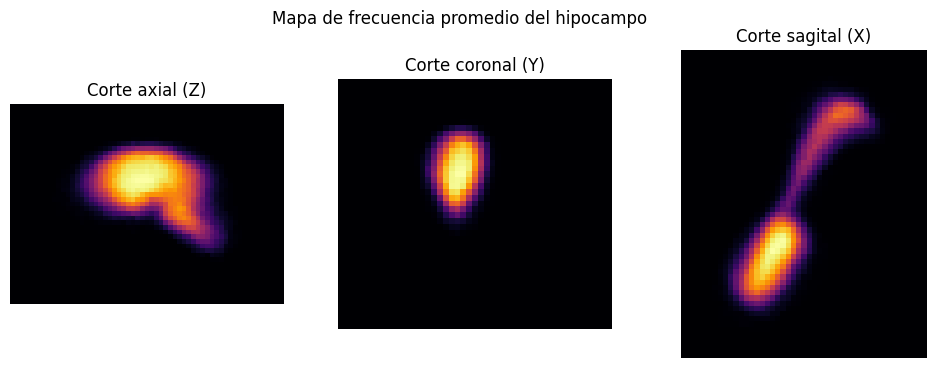

In [40]:
LBL_PAD = "/content/Task04_Hippocampus/labelsTr_pad"
files = sorted([f for f in os.listdir(LBL_PAD) if f.endswith((".nii", ".nii.gz")) and not f.startswith("._")])

sum_mask = None
for f in files:
    arr = np.asanyarray(nib.load(os.path.join(LBL_PAD, f)).dataobj)
    bin_mask = (arr > 0).astype(np.float32)
    if sum_mask is None:
        sum_mask = bin_mask
    else:
        sum_mask += bin_mask

# Promedio: frecuencia relativa del hipocampo por voxel
freq_map = sum_mask / len(files)
print("Mapa de frecuencia calculado. Rango:", freq_map.min(), "→", freq_map.max())


print(f"Mapa de frecuencia guardado en {out_path}")

z, y, x = [s // 2 for s in freq_map.shape]
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.imshow(freq_map[:, :, z], cmap="inferno")
plt.title("Corte axial (Z)")
plt.subplot(1, 3, 2)
plt.imshow(freq_map[:, y, :], cmap="inferno")
plt.title("Corte coronal (Y)")
plt.subplot(1, 3, 3)
plt.imshow(freq_map[x, :, :], cmap="inferno")
plt.title("Corte sagital (X)")

for ax in plt.gcf().axes:
  ax.axis("off")

plt.suptitle("Mapa de frecuencia promedio del hipocampo")
plt.show()

El mapa de frecuencia se obtiene al promediar todas las máscaras de segmentación binarias (donde cada voxel vale 1 si pertenece al hipocampo y 0 en caso contrario).  
Cada voxel del mapa resultante contiene un valor entre **0 y 1**, que representa la **proporción de pacientes** en los que ese punto fue etiquetado como parte del hipocampo.

### Interpretación de los cortes

- **Corte axial (Z):** muestra la extensión lateral del hipocampo en el plano horizontal.  
  La región brillante en el centro indica la posición promedio donde el hipocampo aparece en la mayoría de los sujetos.

- **Corte coronal (Y):** revela la forma alargada y curva característica del hipocampo en sentido anteroposterior.  
  La concentración alta (amarillo intenso) señala el núcleo más frecuente de la estructura.

- **Corte sagital (X):** refleja la continuidad del hipocampo a lo largo del eje longitudinal del cerebro, mostrando su forma curva y bilateral.


El mapa confirma que el hipocampo tiene una localización espacial **consistente entre sujetos**, concentrada en una región compacta del volumen.  
Las zonas con valores intermedios (naranja o violeta) representan **variaciones anatómicas naturales** o pequeñas diferencias en el proceso de segmentación.

---

## GIFs de las imaganes 3d

In [41]:
!pip -q install imageio

In [43]:
import os, nibabel as nib, numpy as np, imageio.v2 as imageio
from pathlib import Path

IMG_DIR = "/content/Task04_Hippocampus/imagesTr_norm"
LBL_DIR = "/content/Task04_Hippocampus/labelsTr_pad"
OUT_DIR = Path("/content/gifs"); OUT_DIR.mkdir(parents=True, exist_ok=True)

def _minmax_uint8(x):
    x = x.astype(np.float32)
    lo, hi = np.percentile(x, 1), np.percentile(x, 99)
    x = np.clip((x - lo) / max(hi - lo, 1e-6), 0, 1)
    return (x * 255).astype(np.uint8)

def _blend_gray_mask(gray, mask, color=(255, 64, 64), alpha=0.35):
    """gray: (H,W) uint8, mask: (H,W) bool/int>0 -> (H,W,3) uint8"""
    rgb = np.stack([gray]*3, axis=-1).astype(np.float32)
    m = (mask > 0)[..., None].astype(np.float32)
    col = np.array(color, dtype=np.float32)
    rgb = (1 - alpha*m)*rgb + alpha*m*col
    return rgb.clip(0,255).astype(np.uint8)

def _iterate_slices(vol, axis=2):
    """yield (H,W) slices a lo largo del eje axis"""
    if axis == 0:
        for i in range(vol.shape[0]): yield vol[i, :, :]
    elif axis == 1:
        for i in range(vol.shape[1]): yield vol[:, i, :]
    else:
        for i in range(vol.shape[2]): yield vol[:, :, i]

def make_gif_for_file(fname, with_overlay=True, fps=12):
    img_path = os.path.join(IMG_DIR, fname)
    img = np.asanyarray(nib.load(img_path).dataobj)

    # mascara
    msk_path = os.path.join(LBL_DIR, fname)
    mask = None
    if os.path.exists(msk_path):
        mask = np.asanyarray(nib.load(msk_path).dataobj)

    for axis, tag in zip([2,1,0], ["axialZ","coronalY","sagittalX"]):
        frames = []
        for sl in _iterate_slices(img, axis=axis):
            g = _minmax_uint8(sl)
            if with_overlay and (mask is not None):
                # slice correspondiente en la máscara
                if axis == 0: ms = mask[frames.__len__(), :, :]
                elif axis == 1: ms = mask[:, frames.__len__(), :]
                else: ms = mask[:, :, frames.__len__()]
                frame = _blend_gray_mask(g, ms)
            else:
                frame = np.stack([g]*3, axis=-1)
            frames.append(frame)
        out = OUT_DIR / f"{Path(fname).stem}_{tag}.gif"
        imageio.mimsave(out, frames, duration=1.0/max(fps,1))
        print(f"Guardado: {out}")

first = sorted([f for f in os.listdir(IMG_DIR) if f.endswith((".nii",".nii.gz"))])[0]
make_gif_for_file(first, with_overlay=True, fps=12)

Guardado: /content/gifs/hippocampus_001.nii_axialZ.gif
Guardado: /content/gifs/hippocampus_001.nii_coronalY.gif
Guardado: /content/gifs/hippocampus_001.nii_sagittalX.gif


## Ver los Gifs


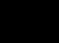
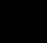
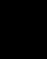

In [55]:
import glob ,base64
from IPython.display import Image, display
from IPython.display import HTML

gifs = sorted(glob.glob("/content/gifs/hippocampus_001*.gif"))
assert gifs, "No se encontraron GIFs en /content/gifs"

def embed_gif(path, width=500):
    with open(path, "rb") as f:
        b64 = base64.b64encode(f.read()).decode("ascii")
    return f"<img src='data:image/gif;base64,{b64}' style='width:{width}px;height:auto;border-radius:8px;'>"

html = "<div style='display:flex;gap:24px;justify-content:center;'>"
for p in gifs:
    html += f"<div style='text-align:center'>{embed_gif(p, width=320)}<br><b>{os.path.basename(p)}</b></div>"
html += "</div>"

display(HTML(html))

## Volumenes 3D Renderizados

In [58]:
import os, nibabel as nib, numpy as np
import plotly.graph_objects as go

ROOT = "/content/Task04_Hippocampus"
IMG_DIR_CAND = [os.path.join(ROOT, "imagesTr_norm"), os.path.join(ROOT, "imagesTr_pad")]
LBL_DIR = os.path.join(ROOT, "labelsTr_pad")

for d in IMG_DIR_CAND:
    if os.path.isdir(d) and any(f.endswith((".nii",".nii.gz")) for f in os.listdir(d)):
        IMG_DIR = d
        break

fname = sorted([f for f in os.listdir(IMG_DIR) if f.endswith((".nii",".nii.gz"))])[0]
img = np.asanyarray(nib.load(os.path.join(IMG_DIR, fname)).dataobj).astype(np.float32)
msk = np.asanyarray(nib.load(os.path.join(LBL_DIR, fname)).dataobj)

STEP = 2
img_ds = img[::STEP, ::STEP, ::STEP]
msk_ds = msk[::STEP, ::STEP, ::STEP]

vals = img_ds[img_ds > 0]
p1, p99 = (np.percentile(vals, 1), np.percentile(vals, 99)) if vals.size else (img_ds.min(), img_ds.max())
img_vis = np.clip((img_ds - p1) / max(p99 - p1, 1e-6), 0, 1)

nx, ny, nz = img_vis.shape
x = np.arange(nx); y = np.arange(ny); z = np.arange(nz)
X, Y, Z = np.meshgrid(x, y, z, indexing="ij")

fig = go.Figure()

fig.add_trace(go.Volume(
    x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
    value=img_vis.flatten(),
    opacity=0.08,
    surface_count=12,
    colorscale='Gray',
    showscale=False,))

for cls, cmap, op in [(1, 'Reds', 0.45), (2, 'Blues', 0.45)]:
    binm = (msk_ds == cls).astype(np.float32)
    if binm.sum() == 0:
        continue

    fig.add_trace(go.Isosurface(
        x=X.flatten(), y=Y.flatten(), z=Z.flatten(),
        value=binm.flatten(),
        isomin=0.5, isomax=1.0,
        surface_count=1,
        caps=dict(x_show=False, y_show=False, z_show=False),
        opacity=op,
        colorscale=cmap,
        showscale=False,
        name=f"mask_{cls}",))

fig.update_layout(
    title=f"3D Volume Rendering — {fname}",
    scene=dict(
        xaxis_title="X", yaxis_title="Y", zaxis_title="Z",
        aspectmode="data"),
    margin=dict(l=0, r=0, t=40, b=0),)

fig.show()

Además del análisis por cortes, es posible representar el **mapa de frecuencia promedio** como un **volumen 3D renderizado**.  
En este caso, cada voxel tiene un valor entre 0 y 1 que indica la **proporción de sujetos** en los que dicho punto fue etiquetado como parte del hipocampo.

Al renderizar este volumen en 3D ( con `plotly` o `itkwidgets`), se pueden visualizar **isosuperficies** que representan distintos niveles de probabilidad:
- Valores altos (≈0.8–1.0): zonas donde el hipocampo está presente en casi todos los individuos.
- Valores medios (≈0.4–0.7): regiones con mayor variabilidad anatómica.
- Valores bajos (<0.3): límites externos o áreas con menos coincidencia.

Este tipo de visualización permite **entender la localización espacial promedio** del hipocampo y la variabilidad intersujeto de manera intuitiva y anatómicamente coherente.

---

## **Tamaño promedio del ROI (bounding box)**

In [59]:
LBL_DIR = "/content/Task04_Hippocampus/labelsTr_pad"
files = sorted([f for f in os.listdir(LBL_DIR) if f.endswith((".nii", ".nii.gz")) and not f.startswith("._")])

bbox_stats = []

def bbox_from_mask(mask):
    pos = np.where(mask > 0)
    if len(pos[0]) == 0: return None
    x_min, x_max = pos[0].min(), pos[0].max()
    y_min, y_max = pos[1].min(), pos[1].max()
    z_min, z_max = pos[2].min(), pos[2].max()
    return (x_max - x_min + 1, y_max - y_min + 1, z_max - z_min + 1)

for f in files:
    arr = np.asanyarray(nib.load(os.path.join(LBL_DIR, f)).dataobj)
    bbox = bbox_from_mask(arr)
    if bbox:
        bbox_stats.append(dict(file=f, x=bbox[0], y=bbox[1], z=bbox[2]))

df_bbox = pd.DataFrame(bbox_stats)
display(df_bbox.describe())

mean_shape = tuple(df_bbox[["x","y","z"]].mean().round().astype(int))
max_shape = tuple(df_bbox[["x","y","z"]].max().astype(int))
print(f"Tamaño promedio del ROI: {mean_shape}")
print(f"Tamaño máximo observado: {max_shape}")

,x,y,z
count,260.000000,260.000000,260.000000
mean,22.038462,38.830769,25.473077
std,2.071703,3.345344,4.020609
min,17.000000,29.000000,14.000000
25%,21.000000,37.000000,23.000000
50%,22.000000,39.000000,26.000000
75%,23.250000,41.000000,28.000000
max,27.000000,48.000000,37.000000


Tamaño promedio del ROI: (22, 39, 25)
Tamaño máximo observado: (27, 48, 37)


El cálculo del *bounding box* para cada máscara indica el volumen mínimo que contiene completamente el hipocampo en cada sujeto.  
A partir de las 260 máscaras analizadas, se obtuvieron los siguientes resultados presentados arriba.

* **Tamaño promedio del ROI:** (22, 39, 25)  
* **Tamaño máximo observado:** (27, 48, 37)

### Analisis
- El hipocampo ocupa un volumen relativamente **compacto y consistente** entre sujetos, con variaciones moderadas (<10 voxeles por eje).  
- La mayor extensión se da en el eje **Y**, lo que corresponde a su forma alargada anteroposterior dentro del cerebro.  
- Estos valores permiten definir un tamaño de parche (*patch size*) adecuado para el modelo 3D U-Net.  
  Un tamaño sugerido sería **(32, 48, 40)**, ya que cubre holgadamente el ROI máximo y proporciona contexto adicional al modelo.  

Este análisis garantiza que el *patch size* capture el hipocampo completo en todas las muestras sin incluir excesivo fondo o regiones irrelevantes.

# **Créditos**
---

* **Profesor:** [Fabio Augusto Gonzalez](https://dis.unal.edu.co/~fgonza/)
* **Asistentes docentes :**
  * [Santiago Toledo Cortés](https://sites.google.com/unal.edu.co/santiagotoledo-cortes/)
* **Diseño de imágenes:**
    - [Mario Andres Rodriguez Triana](https://www.linkedin.com/in/mario-andres-rodriguez-triana-394806145/).
* **Coordinador de virtualización:**
    - [Edder Hernández Forero](https://www.linkedin.com/in/edder-hernandez-forero-28aa8b207/).

**Universidad Nacional de Colombia** - *Facultad de Ingeniería*